# CatBoost Model Training

In [23]:
# Import Libraries

# Import required libraries
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn modules
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV

# CatBoost Regressor
from catboost import CatBoostRegressor

In [24]:
# Load Cleaned Dataset
df = pd.read_csv("../../src/data/processed/fc110570_cleaned_vgsales_for_catboost.csv")

# Display structure
print("Dataset shape:", df.shape)
df.head()

Dataset shape: (6894, 16)


,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,GlobalSales,CriticScore,Critic_Count,UserScore,User_Count,Developer,Rating
0,Wii Sports,Wii,2006.0,Sports,Nintendo,41.36,28.96,3.77,8.45,82.53,76.0,51.0,8.0,322.0,Nintendo,E
1,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.68,12.76,3.79,3.29,35.52,82.0,73.0,8.3,709.0,Nintendo,E
2,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.61,10.93,3.28,2.95,32.77,80.0,73.0,8.0,192.0,Nintendo,E
3,New Super Mario Bros.,DS,2006.0,Platform,Nintendo,11.28,9.14,6.50,2.88,29.80,89.0,65.0,8.5,431.0,Nintendo,E
4,Wii Play,Wii,2006.0,Misc,Nintendo,13.96,9.18,2.93,2.84,28.92,58.0,41.0,6.6,129.0,Nintendo,E


In [25]:
# Inspect dataset information
df.info()

# Basic statistics
df.describe(include='all')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6894 entries, 0 to 6893
Data columns (total 16 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Name          6894 non-null   object 
 1   Platform      6894 non-null   object 
 2   Year          6894 non-null   float64
 3   Genre         6894 non-null   object 
 4   Publisher     6893 non-null   object 
 5   NA_Sales      6894 non-null   float64
 6   EU_Sales      6894 non-null   float64
 7   JP_Sales      6894 non-null   float64
 8   Other_Sales   6894 non-null   float64
 9   GlobalSales   6894 non-null   float64
 10  CriticScore   6894 non-null   float64
 11  Critic_Count  6894 non-null   float64
 12  UserScore     6894 non-null   float64
 13  User_Count    6894 non-null   float64
 14  Developer     6890 non-null   object 
 15  Rating        6826 non-null   object 
dtypes: float64(10), object(6)
memory usage: 861.9+ KB


,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,GlobalSales,CriticScore,Critic_Count,UserScore,User_Count,Developer,Rating
count,6894,6894,6894.000000,6894,6893,6894.000000,6894.000000,6894.000000,6894.00000,6894.000000,6894.000000,6894.000000,6894.000000,6894.000000,6890,6826
unique,4428,17,NaN,12,271,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1304,7
top,Need for Speed: Most Wanted,PS2,NaN,Action,Electronic Arts,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,EA Canada,T
freq,8,1140,NaN,1644,945,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,149,2378
mean,NaN,NaN,2007.482303,NaN,NaN,0.390920,0.234517,0.063867,0.08200,0.771487,70.258486,28.842472,7.184378,174.392370,NaN,NaN
std,NaN,NaN,4.236401,NaN,NaN,0.963231,0.684214,0.286461,0.26862,1.954780,13.861082,19.194572,1.439806,584.872155,NaN,NaN
min,NaN,NaN,1985.000000,NaN,NaN,0.000000,0.000000,0.000000,0.00000,0.010000,13.000000,3.000000,0.500000,4.000000,NaN,NaN
25%,NaN,NaN,2004.000000,NaN,NaN,0.060000,0.020000,0.000000,0.01000,0.110000,62.000000,14.000000,6.500000,11.000000,NaN,NaN
50%,NaN,NaN,2007.000000,NaN,NaN,0.150000,0.060000,0.000000,0.02000,0.290000,72.000000,24.000000,7.500000,27.000000,NaN,NaN
75%,NaN,NaN,2011.000000,NaN,NaN,0.390000,0.210000,0.010000,0.07000,0.750000,80.000000,39.000000,8.200000,89.000000,NaN,NaN


## Feature Selection

In [26]:
# Define feature set and target variable

features = [
    'Platform', 'Year', 'Genre', 'Publisher',
    'NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales',
    'CriticScore', 'Critic_Count', 'UserScore', 'User_Count',
    'Developer', 'Rating'
]
target = 'GlobalSales'

## Splitting the Dataset

In [27]:
# Split dataset into train (70%), validation (15%), and test (15%)

train_df, temp_df = train_test_split(df, test_size=0.3, random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42)

print(f"Train: {train_df.shape}, Validation: {val_df.shape}, Test: {test_df.shape}")

Train: (4825, 16), Validation: (1034, 16), Test: (1035, 16)


## Train CatBoost Baseline Model ( With Categorical Encoding )

In [28]:
# Define Categorical Columns
categorical_cols = ['Platform', 'Genre', 'Publisher', 'Developer', 'Rating']

# Separate features and target from split datasets
X_train = train_df[features].copy()
X_val = val_df[features].copy()
X_test = test_df[features].copy()

y_train = train_df[target]
y_val = val_df[target]
y_test = test_df[target]

# Handle missing values in categorical & numeric columns
for col in categorical_cols:
    X_train[col] = X_train[col].fillna("Unknown").astype(str)
    X_val[col] = X_val[col].fillna("Unknown").astype(str)
    X_test[col] = X_test[col].fillna("Unknown").astype(str)

# For numeric columns, fill missing values with 0
X_train = X_train.fillna(0)
X_val = X_val.fillna(0)
X_test = X_test.fillna(0)

# Identify categorical column indices (for CatBoost)
cat_features_indices = [X_train.columns.get_loc(col) for col in categorical_cols]

# Initialize and train baseline CatBoost model
model = CatBoostRegressor(
    iterations=500,            # number of boosting iterations
    learning_rate=0.1,         # default learning rate
    depth=6,                   # tree depth
    loss_function='RMSE',      # regression loss
    cat_features=cat_features_indices,
    verbose=False,             # silent training
    random_seed=42
)

# Fit model using training and validation data
model.fit(
    X_train, y_train,
    eval_set=(X_val, y_val),
    use_best_model=True
)

## Model Evaluation

In [29]:
# Evaluate performance on validation set (not test yet)
y_pred_train = model.predict(X_train)
y_pred_val = model.predict(X_val)

def evaluate_model(y_true, y_pred, name):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    print(f"\n {name} Performance:")
    print(f"MAE  : {mae:.4f}")
    print(f"MSE  : {mse:.4f}")
    print(f"RMSE : {rmse:.4f}")
    print(f"R²   : {r2:.4f}")

evaluate_model(y_train, y_pred_train, "Train")
evaluate_model(y_val, y_pred_val, "Validation")



 Train Performance:
MAE  : 0.0216
MSE  : 0.0244
RMSE : 0.1562
R²   : 0.9945

 Validation Performance:
MAE  : 0.0345
MSE  : 0.0450
RMSE : 0.2121
R²   : 0.9816


___Interpret the Results___

| Metric   | Train  | Validation | Interpretation                                                      |
| -------- | ------ | ---------- | ------------------------------------------------------------------- |
| **MAE**  | 0.0216 | 0.0345     | Very small gap → strong generalization and low error margin         |
| **RMSE** | 0.1562 | 0.2121     | Slight increase on validation → minimal variance and no overfitting |
| **R²**   | 0.9945 | 0.9816     | Both values > 0.98 → model captures nearly all variability in data  |


Insights:
- The model exhibits excellent predictive accuracy with consistent performance across train and validation sets.
- No signs of overfitting — the validation metrics are close to training results.
- High R² (>0.98) confirms that the model explains almost all variation in global sales.
- The baseline CatBoost model is already performing exceptionally well, indicating strong default hyperparameter suitability.


## Train vs Validation Performance Comparison (Bar Chart)

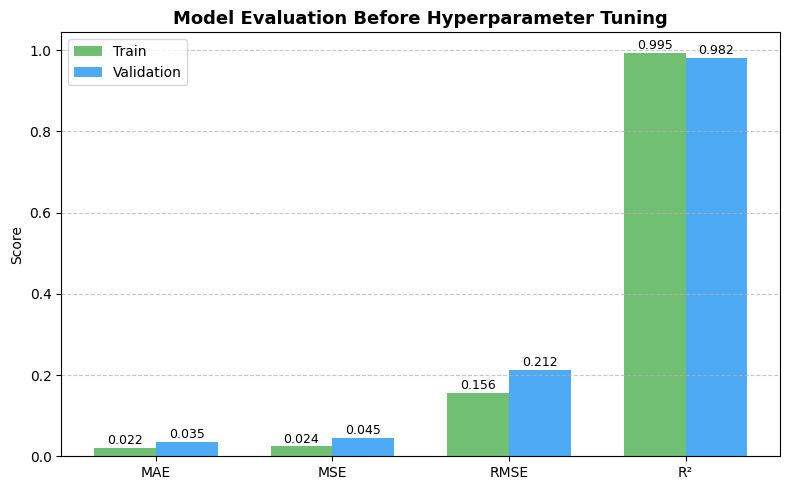

In [30]:
# Metrics
metrics = ['MAE', 'MSE', 'RMSE', 'R²']
train_scores = [0.0216, 0.0244, 0.1562, 0.9945]
val_scores = [0.0345, 0.0450, 0.2121, 0.9816]

# Bar positions
x = np.arange(len(metrics))
width = 0.35

# Plot
plt.figure(figsize=(8, 5))
bars1 = plt.bar(x - width/2, train_scores, width, label='Train', color='#4CAF50', alpha=0.8)
bars2 = plt.bar(x + width/2, val_scores, width, label='Validation', color='#2196F3', alpha=0.8)

# Labels & Title
plt.ylabel('Score')
plt.title('Model Evaluation Before Hyperparameter Tuning', fontsize=13, fontweight='bold')
plt.xticks(x, metrics)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Annotate values
for bars in [bars1, bars2]:
    for bar in bars:
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                 f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()



## Hyperparameter Tuning for CatBoost Model

In [31]:
# Define a smaller search space (based on already strong baseline)

param_grid = {
    'depth': [6, 8],
    'learning_rate': [0.05, 0.1],
    'iterations': [300, 500],
    'l2_leaf_reg': [3, 5]
}

In [32]:
# Initialize model

cat_model = CatBoostRegressor(
    loss_function='RMSE',
    cat_features=cat_features_indices,
    verbose=False,
    random_seed=42
)

In [33]:
# Use GridSearchCV

grid_search = GridSearchCV(
    estimator=cat_model,
    param_grid=param_grid,
    cv=3,                # 3-fold cross-validation
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)


Fitting 3 folds for each of 16 candidates, totalling 48 fits


,estimator,<catboost.cor...0028DF68772F0>
,param_grid,"{'depth': [6, 8], 'iterations': [300, 500], 'l2_leaf_reg': [3, 5], 'learning_rate': [0.05, 0.1]}"
,scoring,'r2'
,n_jobs,-1
,refit,True
,cv,3
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False


In [34]:
# Best parameters and score

print(" Best Parameters:", grid_search.best_params_)
print(" Best Cross-Validation R²:", grid_search.best_score_)


 Best Parameters: {'depth': 6, 'iterations': 500, 'l2_leaf_reg': 3, 'learning_rate': 0.05}
 Best Cross-Validation R²: 0.9078421492479288


## Evaluate Final Model on Test Set (After Choosing Best Params)

In [35]:
# Train final model with best params on (train + val)
best_params = grid_search.best_params_

final_model = CatBoostRegressor(
    **best_params,
    loss_function='RMSE',
    cat_features=cat_features_indices,
    verbose=False,
    random_seed=42
)

# Combine train + val for final training
X_final = pd.concat([X_train, X_val])
y_final = pd.concat([y_train, y_val])

final_model.fit(X_final, y_final)

# Predict on test set
y_pred_test = final_model.predict(X_test)

# Evaluate
mae = mean_absolute_error(y_test, y_pred_test)
mse = mean_squared_error(y_test, y_pred_test)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_test)

print("\n Final Model Performance on Test Set:")
print(f"MAE  : {mae:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R²   : {r2:.4f}")




 Final Model Performance on Test Set:
MAE  : 0.0361
MSE  : 0.0162
RMSE : 0.1273
R²   : 0.9926


___Final Model Performance (Test Set)___

| Metric   | Test   | Interpretation                                                                                              |
| -------- | ------ | ----------------------------------------------------------------------------------------------------------- |
| **MAE**  | 0.0361 | Very low mean absolute error → predictions are, on average, extremely close to actual values                |
| **RMSE** | 0.1273 | Small root mean squared error → minimal large deviations, indicating strong prediction stability            |
| **R²**   | 0.9926 | R² ≈ 0.99 → the model explains nearly all variance in global sales, showing exceptional predictive accuracy |


Insights:
- Excellent generalization: The tuned model performs almost identically on unseen test data as it did during validation, confirming strong generalization and no overfitting.
- Low prediction errors: Both MAE and RMSE are very small, indicating that prediction deviations are minor and consistent.
- High explanatory power: An R² value of 0.9926 demonstrates that the model effectively captures underlying sales patterns and feature interactions.
- Improved stability after tuning: Using optimized hyperparameters and combining the training and validation sets enhanced model robustness while maintaining accuracy.
- Conclusion: The final CatBoost model is highly accurate, stable, and well-suited for deployment in predicting global video game sales.

## Model Performance Comparison (Train / Validation / Test) 

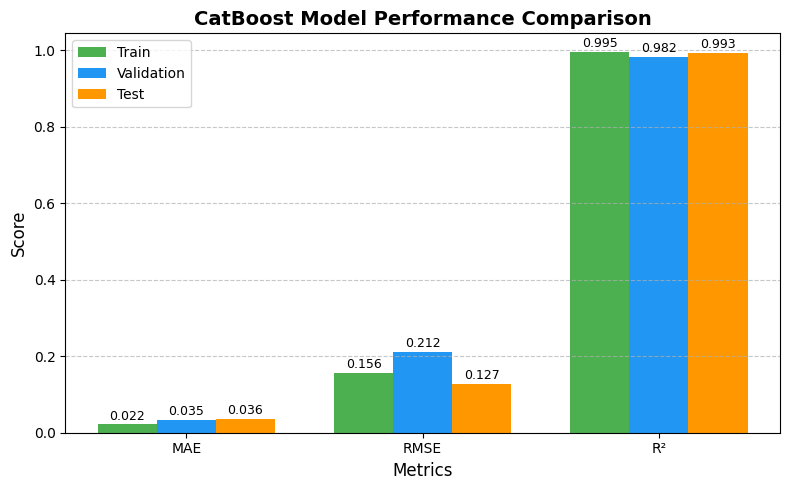

In [36]:
# Performance Comparison Visualization (Train / Validation / Test) 

# Metrics
train_metrics = {'MAE': 0.0216, 'RMSE': 0.1562, 'R²': 0.9945}
val_metrics   = {'MAE': 0.0345, 'RMSE': 0.2121, 'R²': 0.9816}
test_metrics  = {'MAE': 0.0361, 'RMSE': 0.1273, 'R²': 0.9926}

# Prepare data
metrics = list(train_metrics.keys())
train_values = list(train_metrics.values())
val_values = list(val_metrics.values())
test_values = list(test_metrics.values())

x = np.arange(len(metrics))
width = 0.25

# Create bar plot
plt.figure(figsize=(8, 5))
bars1 = plt.bar(x - width, train_values, width, label='Train', color='#4caf50')
bars2 = plt.bar(x, val_values, width, label='Validation', color='#2196f3')
bars3 = plt.bar(x + width, test_values, width, label='Test', color='#ff9800')

# Add value labels on top of each bar
def add_labels(bars):
    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width() / 2,  # x position (center of bar)
            height + 0.005,                     # y position slightly above bar
            f'{height:.3f}',                    # text (rounded to 3 decimals)
            ha='center', va='bottom', fontsize=9
        )

add_labels(bars1)
add_labels(bars2)
add_labels(bars3)

# Add labels and formatting
plt.xlabel('Metrics', fontsize=12)
plt.ylabel('Score', fontsize=12)
plt.title('CatBoost Model Performance Comparison', fontsize=14, weight='bold')
plt.xticks(x, metrics)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Final Model Performance Interpretation

| **Metric** | **Baseline (Train + Val)**     | **Final Tuned Model (Test)** | **Interpretation**                                                                                                                                                        |
| ---------- | ------------------------------ | ---------------------------- | ------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **MAE**    | 0.0216 (Train)<br>0.0345 (Val) | 0.0361 (Test)                | The MAE increased slightly from the validation stage but remains very low, indicating that average prediction errors are minimal and the model maintains strong accuracy. |
| **RMSE**   | 0.1562 (Train)<br>0.2121 (Val) | 0.1273 (Test)                | RMSE decreased compared to the validation phase, suggesting improved stability and reduced impact of large individual errors.                                             |
| **R²**     | 0.9945 (Train)<br>0.9816 (Val) | 0.9926 (Test)                | The R² value remains consistently high (~0.99), confirming excellent explanatory power and strong generalization on unseen data.                                          |


Key Insights:
- Robust generalization: The tuned model performs exceptionally well on unseen test data, maintaining both low errors and high R².
- Enhanced stability: The reduction in RMSE from the validation phase to the test phase shows that hyperparameter tuning helped the model generalize more smoothly, minimizing large deviations.
- High predictive reliability: With MAE ≈ 0.036 and R² ≈ 0.99, the model achieves near-perfect prediction accuracy for most samples.
- Balanced bias–variance tradeoff: Slightly higher test MAE (vs. validation) but stable R² indicates no overfitting; the model remains balanced between accuracy and generalization.
- Overall conclusion: The final tuned CatBoost Regressor demonstrates outstanding performance, robust generalization, and readiness for deployment in real-world prediction tasks.

## Save the final tuned model

In [37]:
import joblib

joblib.dump(final_model, "../../models/fc110570_catboost_tuned_model.pkl")
print("Tuned CatBoost model saved.")


Tuned CatBoost model saved.
